# Magic Methods (Dunder) – Customize Behavior with __str__, __add__, __eq__, etc.
<img src="Dunder_methods.png" alt="Dunder_methods.png" width="65%" /></a>


Welcome to the eighth notebook in our Object-Oriented Programming (OOP) for Computer Vision series! In this tutorial, we'll explore magic methods (also known as dunder methods) in Python, which allow you to customize the behavior of your classes in powerful ways.

## Table of Contents
1. [Introduction to Magic Methods](#introduction)
2. [String Representation: `__str__` and `__repr__`](#string-representation)
3. [Comparison Magic Methods: `__eq__`, `__lt__`, etc.](#comparison-methods)
4. [Mathematical Operations: `__add__`, `__sub__`, etc.](#mathematical-operations)
5. [Container Methods: `__len__`, `__getitem__`, etc.](#container-methods)
6. [Exercises](#exercises)
7. [Conclusion](#conclusion)

In [ ]:
res1 = 3+5
res2 = (5).__add__(3)
res3 = int.__add__(3,5)

print(f"Are they the same{res1==res2==res3}")

In [ ]:
class Dog:
    def __init__(self,name, age):
        self.name = name
        self.age = age

    # def __repr__(self):
    #     return f"Dog('{self.name}',{self.age})"
    
    # def __str__(self):
    #     return f"Dog: '{self.name}',{self.age}"
    
        

d1 = Dog("Bubby", 3)

print(d1)
print(repr(d1))
print(d1.__repr__())
print(d1.__str__())
        

## 1. Introduction to Magic Methods <a name="introduction"></a>

Magic methods (or dunder methods, short for "double underscore") are special methods in Python that start and end with double underscores. They allow you to define how your objects behave in various contexts, such as when they're printed, compared, added, or accessed like containers.

These methods are "magical" because they're automatically called by Python in response to certain operations or syntax. For example, when you use the `+` operator on two objects, Python calls the `__add__` method of the left operand.

Let's start by importing the necessary libraries for our examples:

In [ ]:
class Dog:
    def __init__(self, name, age):
        self.name = name
        self.age = age

# Create a dog
my_dog = Dog("Buddy", 3)

# Let's see what happens when we print it


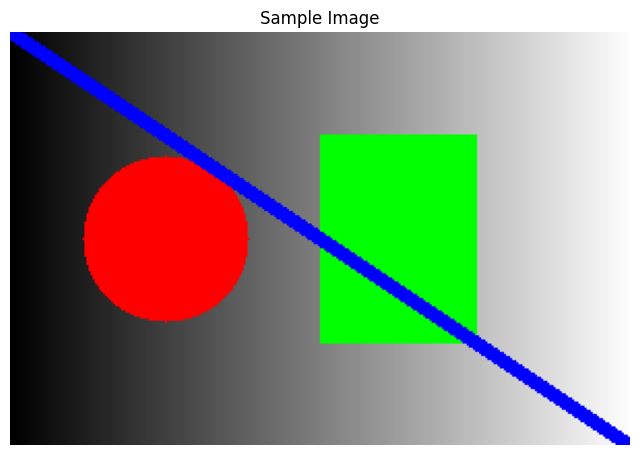

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import os

# Helper function to display images
def display_image(image, title="Image"):
    plt.figure(figsize=(8, 6))
    if len(image.shape) == 3:  # Color image
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:  # Grayscale image
        plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()
    
# Create a sample image (a simple gradient with shapes)
def create_sample_image(width=300, height=200):
    # Create a gradient from black to white
    gradient = np.zeros((height, width), dtype=np.uint8)
    for i in range(width):
        gradient[:, i] = int(255 * i / width)
    
    # Convert to a color image (BGR)
    color_gradient = cv2.cvtColor(gradient, cv2.COLOR_GRAY2BGR)
    
    # Add some shapes
    cv2.circle(color_gradient, (width//4, height//2), 40, (0, 0, 255), -1)  # Red circle
    cv2.rectangle(color_gradient, (width//2, height//4), (3*width//4, 3*height//4), (0, 255, 0), -1)  # Green rectangle
    cv2.line(color_gradient, (0, 0), (width, height), (255, 0, 0), 5)  # Blue line
    
    return color_gradient

# Create a sample image
sample_image = create_sample_image()

# Display the sample image
display_image(sample_image, "Sample Image")

## 2. String Representation: `__str__` and `__repr__` <a name="string-representation"></a>

Two of the most commonly used magic methods are `__str__` and `__repr__`, which control how an object is converted to a string.

- `__str__`: Called by the `str()` function and by the `print()` function. It should return a human-readable string representation of the object.
- `__repr__`: Called by the `repr()` function and when displaying objects in the interactive console. It should return a string that, ideally, could be used to recreate the object.

Let's create a simple `Image` class with these methods:

In [ ]:
class Image:
    def __init__(self, data, name="Unnamed"):
        self.data = data
        self.name = name
        self.shape = data.shape if data is not None else None
        self.creation_time = datetime.now()
    
    def __str__(self):
        if self.data is None:
            return f"Image '{self.name}' No Data"
        
        height, width = self.shape[:2]
        channel = 1 if len(self.shape)==2 else self.shape[2]
        color_type = "Grayscale" if channel ==1 else "Color"
        
        return f" Image '{self.name}' ({height, width}), {color_type}"
    
    def __repr__(self):
        if self.data is None:
            return f"Image(None, '{self.name}') "
        
        return f" Image(array(shape={self.data.shape}, dtype={self.data.dtype}),name= '{self.name}')"
    
    img = Image(sample_image,"Sample")
    
    print(img)
    print( str(img))        
    print(repr(img))                
        
        

### When to Use `__str__` vs `__repr__`

- Use `__str__` for a human-friendly representation that focuses on readability.
- Use `__repr__` for a more detailed, unambiguous representation that ideally allows recreation of the object.

If you only implement one, implement `__repr__`, as Python will fall back to it if `__str__` is not defined. However, it's best practice to implement both for clarity.

## 3. Comparison Magic Methods: `__eq__`, `__lt__`, etc. <a name="comparison-methods"></a>

Python provides several magic methods to customize how objects are compared:

- `__eq__(self, other)`: Called by the `==` operator.
- `__ne__(self, other)`: Called by the `!=` operator.
- `__lt__(self, other)`: Called by the `<` operator.
- `__le__(self, other)`: Called by the `<=` operator.
- `__gt__(self, other)`: Called by the `>` operator.
- `__ge__(self, other)`: Called by the `>=` operator.

Let's extend our `Image` class to support comparison based on image dimensions:

In [27]:
class Image:
    def __init__(self, data, name="Unnamed"):
        self.data = data
        self.name = name
        self.shape = data.shape if data is not None else None
        self.creation_time = datetime.now()

    
    def __str__(self):
        if self.data is None:
            return f"Image '{self.name}' (No data)"
        
        height, width = self.data.shape[:2]
        channels = 1 if len(self.data.shape) == 2 else self.data.shape[2]
        color_type = "Grayscale" if channels == 1 else "Color"
        
        return f"Image '{self.name}' ({width}x{height}, {color_type})"
    
    def __repr__(self):
        if self.data is None:
            return f"Image(None, name='{self.name}')"
        
        return f"Image(array(shape={self.data.shape}, dtype={self.data.dtype}), name='{self.name}')"
    
    def __eq__(self, other):
        """Check if two images have the same dimensions and data."""
        if not isinstance(other, Image):
            return False
        
        if self.data is None or other.data is None:
            return self.data is None and other.data is None
        
        # Compare shapes and data
        return (self.data.shape == other.data.shape and 
                np.array_equal(self.data, other.data))
    
    def __lt__(self, other):
        """Compare images based on total number of pixels (width * height)."""
        if not isinstance(other, Image) or self.data is None or other.data is None:
            return NotImplemented
        
        self_pixels = self.data.shape[0] * self.data.shape[1]
        other_pixels = other.data.shape[0] * other.data.shape[1]
        
        return self_pixels < other_pixels
    
    def __le__(self, other):
        """Compare images based on total number of pixels (width * height)."""
        if not isinstance(other, Image) or self.data is None or other.data is None:
            return NotImplemented
        
        self_pixels = self.data.shape[0] * self.data.shape[1]
        other_pixels = other.data.shape[0] * other.data.shape[1]
        
        return self_pixels <= other_pixels
    
    def __gt__(self, other):
        """Compare images based on total number of pixels (width * height)."""
        if not isinstance(other, Image) or self.data is None or other.data is None:
            return NotImplemented
        
        self_pixels = self.data.shape[0] * self.data.shape[1]
        other_pixels = other.data.shape[0] * other.data.shape[1]
        
        return self_pixels > other_pixels
    
    def __ge__(self, other):
        """Compare images based on total number of pixels (width * height)."""
        if not isinstance(other, Image) or self.data is None or other.data is None:
            return NotImplemented
        
        self_pixels = self.data.shape[0] * self.data.shape[1]
        other_pixels = other.data.shape[0] * other.data.shape[1]
        
        return self_pixels >= other_pixels

# Create some Image objects with different dimensions
img1 = Image(sample_image, "Sample 300x200")
img2 = Image(create_sample_image(400, 300), "Sample 400x300")
img3 = Image(create_sample_image(300, 200), "Sample 300x200 (copy)")

d1 = Dog("Bubby", 3)

# Test equality
print(f"img1 == img2: {img1 == img2}")  # Should be False (different dimensions)
print(f"img1 == img3: {img1 == img3}")  # Should be False (same dimensions but different data)

# Create a true copy
img4 = Image(img1.data.copy(), "Sample 300x200 (true copy)")
print(f"img1 == img4: {img1 == img4}")  # Should be True (same data)

# Test comparison operators
print(f"img1 < img2: {img1 < img2}")   # Should be True (300x200 < 400x300)
print(f"img1 <= img3: {img1 <= img3}") # Should be True (same dimensions)
print(f"img2 > img1: {img2 > img1}")   # Should be True (400x300 > 300x200)
print(f"img2 >= img3: {img2 >= img3}") # Should be True (400x300 >= 300x200)    

# print(f"img2 >= d1: {img2 >= d1}") # Should be True (400x300 >= 300x200)    

img1 == img2: False
img1 == img3: True
img1 == img4: True
img1 < img2: True
img1 <= img3: True
img2 > img1: True
img2 >= img3: True


### The `NotImplemented` Value

Notice that we return `NotImplemented` (not to be confused with `NotImplementedError`) when the comparison doesn't make sense (e.g., comparing an `Image` with a non-`Image` object). This tells Python to try the reflected operation or fall back to the default behavior.

For example, if `x < y` returns `NotImplemented`, Python will try `y > x`. If that also returns `NotImplemented`, Python will raise a `TypeError`.

## 4. Mathematical Operations: `__add__`, `__sub__`, etc. <a name="mathematical-operations"></a>

Python allows you to define how objects behave with mathematical operators using magic methods:

- `__add__(self, other)`: Called by the `+` operator.
- `__sub__(self, other)`: Called by the `-` operator.
- `__mul__(self, other)`: Called by the `*` operator.
- `__truediv__(self, other)`: Called by the `/` operator.
- `__floordiv__(self, other)`: Called by the `//` operator.
- `__mod__(self, other)`: Called by the `%` operator.
- `__pow__(self, other)`: Called by the `**` operator.

Let's extend our `Image` class to support basic image operations:

In [ ]:
class Image:
    def __init__(self, data, name="Unnamed"):
        self.data = data
        self.name = name
        self.shape = data.shape if data is not None else None
        self.creation_time = datetime.now()
    
    def __str__(self):
        if self.data is None:
            return f"Image '{self.name}' (No data)"
        
        height, width = self.data.shape[:2]
        channels = 1 if len(self.data.shape) == 2 else self.data.shape[2]
        color_type = "Grayscale" if channels == 1 else "Color"
        
        return f"Image '{self.name}' ({width}x{height}, {color_type})"
    
    def __repr__(self):
        if self.data is None:
            return f"Image(None, name='{self.name}')"
        
        return f"Image(array(shape={self.data.shape}, dtype={self.data.dtype}), name='{self.name}')"
    
    def display(self, title=None):
        """Display the image using matplotlib."""
        if self.data is None:
            print(f"Cannot display image: {self.name} (No data)")
            return self
        
        display_title = title if title else self.name
        display_image(self.data, display_title)
        return self
    
    def __add__(self, other):
        """Add two images or add a scalar to an image."""
        if self.data is None:
            return NotImplemented
        
        if isinstance(other, Image):
            # Add two images
            if other.data is None:
                return NotImplemented
            
            if self.data.shape != other.data.shape:
                raise ValueError(f"Cannot add images with different shapes: {self.data.shape} and {other.data.shape}")
            
            result_data = cv2.add(self.data, other.data)
            return Image(result_data, f"{self.name} + {other.name}")
        
        elif isinstance(other, (int, float)):
            # Add a scalar to an image
            result_data = cv2.add(self.data, np.full_like(self.data, other))
            return Image(result_data, f"{self.name} + {other}")
        
        return NotImplemented
    
    def __sub__(self, other):
        """Subtract another image or a scalar from this image."""
        if self.data is None:
            return NotImplemented
        
        if isinstance(other, Image):
            # Subtract another image
            if other.data is None:
                return NotImplemented
            
            if self.data.shape != other.data.shape:
                raise ValueError(f"Cannot subtract images with different shapes: {self.data.shape} and {other.data.shape}")
            
            result_data = cv2.subtract(self.data, other.data)
            return Image(result_data, f"{self.name} - {other.name}")
        
        elif isinstance(other, (int, float)):
            # Subtract a scalar from an image
            result_data = cv2.subtract(self.data, np.full_like(self.data, other))
            return Image(result_data, f"{self.name} - {other}")
        
        return NotImplemented
    
    def __mul__(self, other):
        """Multiply an image by another image or a scalar."""
        if self.data is None:
            return NotImplemented
        
        if isinstance(other, Image):
            # Multiply by another image
            if other.data is None:
                return NotImplemented
            
            if self.data.shape != other.data.shape:
                raise ValueError(f"Cannot multiply images with different shapes: {self.data.shape} and {other.data.shape}")
            
            # Element-wise multiplication, normalized to avoid overflow
            result_data = cv2.multiply(self.data, other.data, scale=1/255)
            return Image(result_data, f"{self.name} * {other.name}")
        
        elif isinstance(other, (int, float)):
            # Multiply by a scalar
            result_data = cv2.multiply(self.data, other)
            return Image(result_data, f"{self.name} * {other}")
        
        return NotImplemented
    
    def __truediv__(self, other):
        """Divide an image by another image or a scalar."""
        if self.data is None:
            return NotImplemented
        
        if isinstance(other, Image):
            # Divide by another image
            if other.data is None:
                return NotImplemented
            
            if self.data.shape != other.data.shape:
                raise ValueError(f"Cannot divide images with different shapes: {self.data.shape} and {other.data.shape}")
            
            # Avoid division by zero
            epsilon = 1e-10
            safe_divisor = np.where(other.data < epsilon, epsilon, other.data)
            
            # Element-wise division
            result_data = cv2.divide(self.data, safe_divisor)
            return Image(result_data, f"{self.name} / {other.name}")
        
        elif isinstance(other, (int, float)):
            # Divide by a scalar
            if abs(other) < 1e-10:
                raise ValueError("Division by zero or near-zero value")
            
            result_data = cv2.divide(self.data, other)
            return Image(result_data, f"{self.name} / {other}")
        
        return NotImplemented
    
    
    



## 5. Container Methods: `__len__`, `__getitem__`, etc. <a name="container-methods"></a>

Python provides magic methods to make your objects behave like containers (e.g., lists, dictionaries):

- `__len__(self)`: Called by the `len()` function.
- `__getitem__(self, key)`: Called when using the indexing syntax `obj[key]`.
- `__setitem__(self, key, value)`: Called when using the assignment syntax `obj[key] = value`.
- `__delitem__(self, key)`: Called when using the `del` statement with indexing syntax `del obj[key]`.
- `__contains__(self, item)`: Called when using the `in` operator.
- `__iter__(self)`: Called when iterating over an object.

Let's extend our `Image` class to support these container operations:

Number of pixels: 60000
Pixel at (100, 150): [255   0   0]


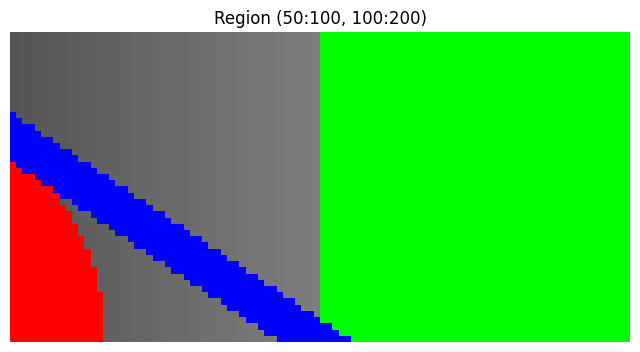

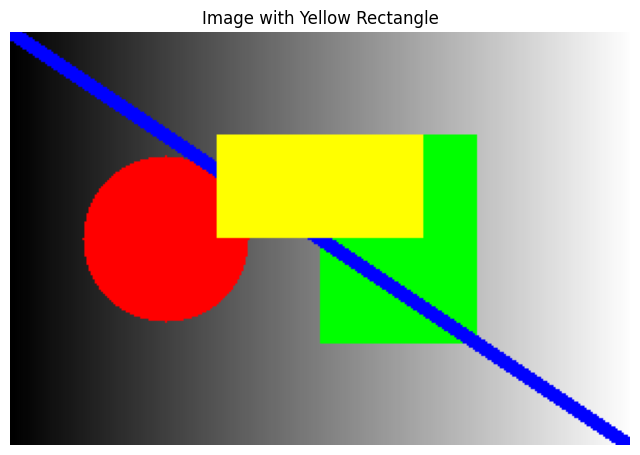

Contains pure red (0, 0, 255)? True
Contains pure yellow (0, 255, 255)? False
Contains pure yellow after modification? True

First 3 rows of the image:
Row 0: shape=(300, 3), min=0, max=255
Row 1: shape=(300, 3), min=0, max=255
Row 2: shape=(300, 3), min=0, max=255


In [4]:
class Image:
    def __init__(self, data, name="Unnamed"):
        self.data = data
        self.name = name
        self.shape = data.shape if data is not None else None
        self.creation_time = datetime.now()
    
    def __str__(self):
        if self.data is None:
            return f"Image '{self.name}' (No data)"
        
        height, width = self.data.shape[:2]
        channels = 1 if len(self.data.shape) == 2 else self.data.shape[2]
        color_type = "Grayscale" if channels == 1 else "Color"
        
        return f"Image '{self.name}' ({width}x{height}, {color_type})"
    
    def __repr__(self):
        if self.data is None:
            return f"Image(None, name='{self.name}')"
        
        return f"Image(array(shape={self.data.shape}, dtype={self.data.dtype}), name='{self.name}')"
    
    def display(self, title=None):
        if self.data is None:
            print(f"Cannot display image: {self.name} (No data)")
            return self
        
        display_title = title if title else self.name
        display_image(self.data, display_title)
        return self
    
    # Container methods
    
    def __len__(self):
        """Return the number of pixels in the image."""
        if self.data is None:
            return 0
        
        return self.data.shape[0] * self.data.shape[1]
    
    def __getitem__(self, key):
        """Get a pixel, row, column, or region of the image."""
        if self.data is None:
            raise ValueError("Cannot index into an empty image")
        
        # Return a new Image object for slices to maintain the class behavior
        if isinstance(key, tuple) and all(isinstance(k, slice) for k in key):
            # Region selection with slices
            region_data = self.data[key]
            return Image(region_data, f"{self.name}[{key}]")
        
        # For other types of indexing, return the raw numpy array data
        return self.data[key]
    
    def __setitem__(self, key, value):
        """Set a pixel, row, column, or region of the image."""
        if self.data is None:
            raise ValueError("Cannot index into an empty image")
        
        self.data[key] = value
    
    def __contains__(self, value):
        """Check if a specific pixel value exists in the image."""
        if self.data is None:
            return False
        
        # For grayscale images, value should be a scalar
        # For color images, value should be a tuple (B, G, R)
        return np.any(np.all(self.data == value, axis=-1 if len(self.data.shape) > 2 else None))
    
    def __iter__(self):
        """Iterate over the rows of the image."""
        if self.data is None:
            return iter([])
        
        return iter(self.data)

# Create an image for testing
img = Image(sample_image, "Sample")

# Test __len__
print(f"Number of pixels: {len(img)}")

# Test __getitem__ for a pixel
pixel = img[100, 150]
print(f"Pixel at (100, 150): {pixel}")

# Test __getitem__ for a region
region = img[50:100, 100:200]
region.display("Region (50:100, 100:200)")

# Test __setitem__
img_copy = Image(img.data.copy(), "Modified Sample")
img_copy[50:100, 100:200] = (0, 255, 255)  # Yellow rectangle
img_copy.display("Image with Yellow Rectangle")

# Test __contains__
print(f"Contains pure red (0, 0, 255)? {(0, 0, 255) in img}")
print(f"Contains pure yellow (0, 255, 255)? {(0, 255, 255) in img}")
print(f"Contains pure yellow after modification? {(0, 255, 255) in img_copy}")

# Test __iter__
print("\nFirst 3 rows of the image:")
for i, row in enumerate(img):
    if i < 3:
        print(f"Row {i}: shape={row.shape}, min={row.min()}, max={row.max()}")
    else:
        break

---

## 🎉 Congratulations!

You've completed the Python Magic Methods tutorial! Here's what you've learned:

### 📚 Key Takeaways

1. **Magic methods** (dunder methods) allow you to customize how your objects behave with built-in operations
2. **String representation** methods (`__str__`, `__repr__`) make your objects more user-friendly
3. **Comparison methods** (`__eq__`, `__lt__`, etc.) enable sorting and equality testing
4. **Arithmetic methods** (`__add__`, `__sub__`, etc.) let your objects work with mathematical operators
5. **Container methods** (`__len__`, `__getitem__`, etc.) make objects behave like lists or dictionaries
6. **Callable objects** (`__call__`) turn objects into function-like entities

### 🎯 Best Practices Recap

- Always check types in magic methods
- Return `NotImplemented` for unsupported operations
- Keep comparison methods consistent
- Don't modify objects in-place for arithmetic operations
- Handle edge cases gracefully

### 🚀 Next Steps

- Practice implementing magic methods in your own classes
- Explore more advanced magic methods like `__getattr__`, `__setattr__`
- Learn about context managers (`__enter__`, `__exit__`)
- Study how popular Python libraries use magic methods

Happy coding! 🐍✨

## 6. Exercises <a name="exercises"></a>

Now that you've learned about magic methods, try these exercises to reinforce your understanding:

### Exercise 1: Implement More Magic Methods

Extend the `ImageArray` class with the following magic methods:

1. `__neg__`: Implement negation (invert the image).
2. `__abs__`: Implement absolute value (useful for gradient images).
3. `__pow__`: Implement power operation (raise pixel values to a power).
4. `__invert__`: Implement bitwise inversion (complement of the image).

### Exercise 2: Create a Histogram Class

Create a `Histogram` class that represents an image histogram with the following magic methods:

1. `__init__`: Initialize with an image.
2. `__str__` and `__repr__`: String representations.
3. `__len__`: Return the number of bins.
4. `__getitem__`: Access histogram values by bin index.
5. `__add__` and `__sub__`: Add or subtract histograms.
6. `__call__`: Calculate and return the histogram for a specific channel.

### Exercise 3: Create an ImageCollection Class

Create an `ImageCollection` class that manages a collection of images with the following magic methods:

1. `__init__`: Initialize with a list of images or a directory path.
2. `__str__` and `__repr__`: String representations.
3. `__len__`: Return the number of images.
4. `__getitem__`: Access images by index.
5. `__iter__`: Iterate over the images.
6. `__contains__`: Check if an image is in the collection.
7. `__call__`: Apply a transformation to all images in the collection.

### Exercise 4: Create a Custom Filter Class

Create a `Filter` class that represents an image filter with the following magic methods:

1. `__init__`: Initialize with a kernel.
2. `__str__` and `__repr__`: String representations.
3. `__call__`: Apply the filter to an image.
4. `__add__` and `__mul__`: Combine filters by adding or multiplying their kernels.
5. `__matmul__`: Compose filters (apply one after the other).

## 10. Conclusion <a name="conclusion"></a>

In this notebook, we've explored magic methods (dunder methods) in Python and how they can be used to customize the behavior of your classes. We've seen how to:

1. Define string representations with `__str__` and `__repr__`.
2. Implement comparison operations with `__eq__`, `__lt__`, etc.
3. Enable mathematical operations with `__add__`, `__sub__`, etc.
4. Make objects behave like containers with `__len__`, `__getitem__`, etc.
5. Create callable objects with `__call__`.
6. Implement context managers with `__enter__` and `__exit__`.

Magic methods are a powerful feature of Python that allow you to create intuitive and expressive interfaces for your classes. By implementing these methods, you can make your objects behave like built-in types, which can lead to more readable and maintainable code.

In the context of computer vision, magic methods can be particularly useful for creating image processing classes that are easy to use and understand. For example, you can use `+` to add images, `[]` to access regions, and `()` to apply transformations.

In the next notebook, we'll explore data classes, which provide a concise way to create classes that are primarily used to store data.